In [30]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns




In [4]:
data = pd.read_csv(r'C:\Users\aliye\Desktop\QSS(DSA)\python\week-4\day-2\USA_Housing.csv')
df = data.copy()
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316
4999,65510.581804,5.992305,6.792336,4.07,46501.283803,1.298950e+06,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [7]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [8]:
df.drop(['Address'], axis=1, inplace=True)

In [9]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


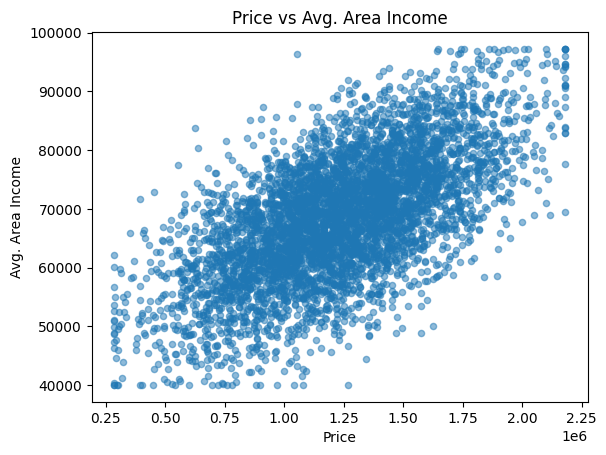

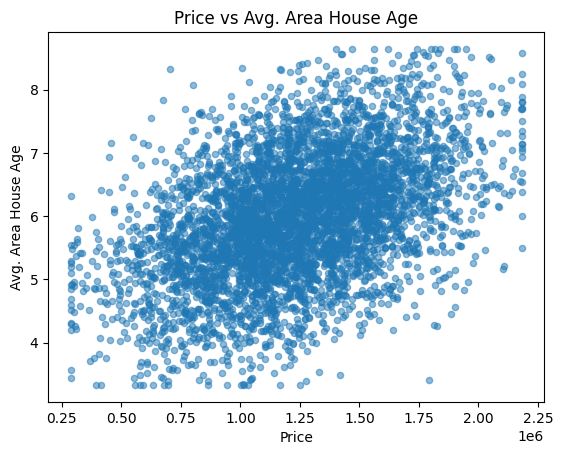

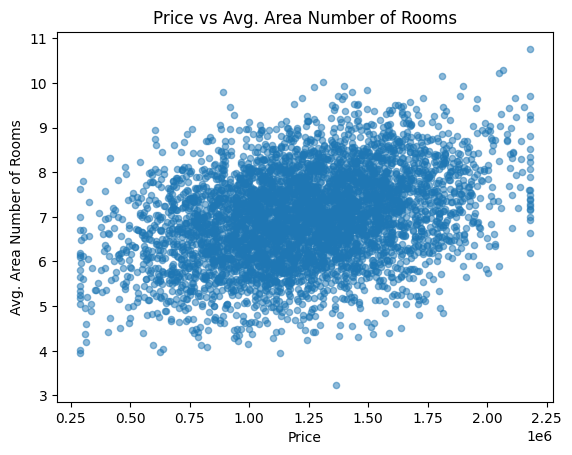

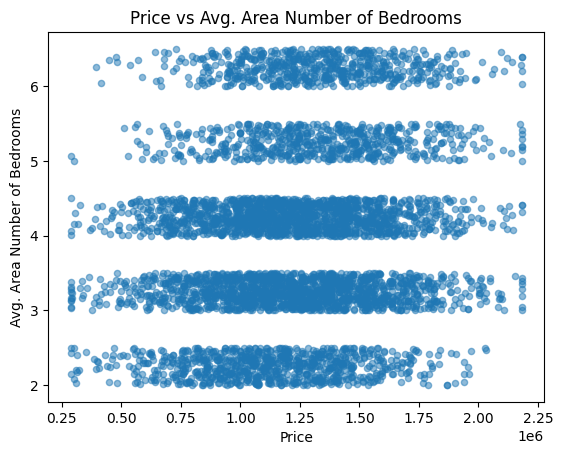

In [35]:
features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms']


for col in features:
    df.plot(x='Price', y=col, kind='scatter', alpha=0.5) # alpha=0.5 noktaların yoğunluğunu görmenizi sağlar
    plt.title(f'Price vs {col}')
    plt.xlabel('Price')
    plt.ylabel(col)
    plt.show()
#kind='scatter': Çizilecek grafiğin türünü belirler. y a bir sutun versek scatter, birden fazla sutun versek line grafiği çizer.

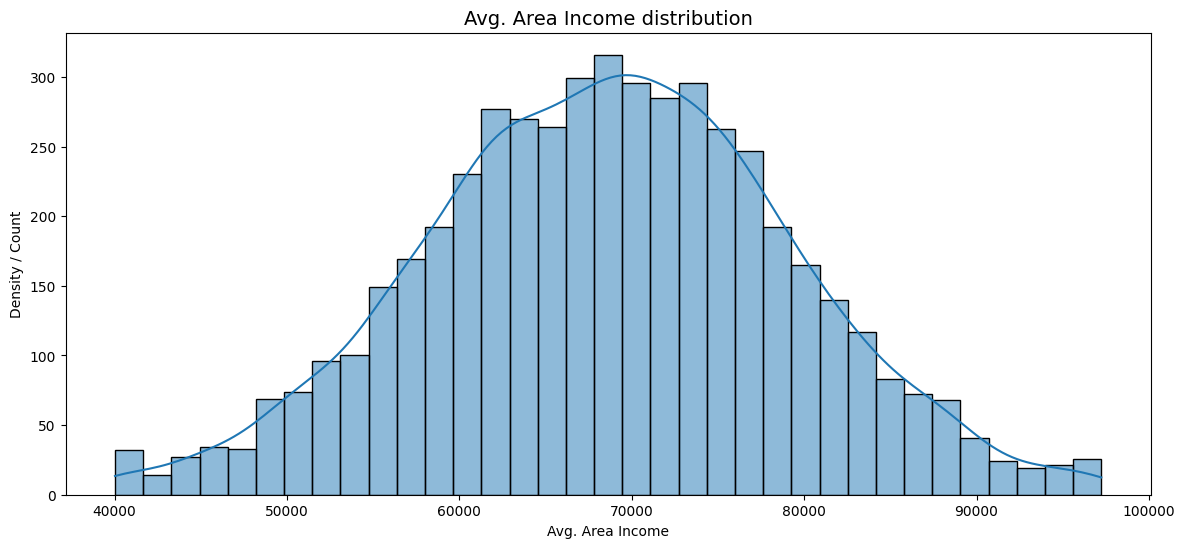

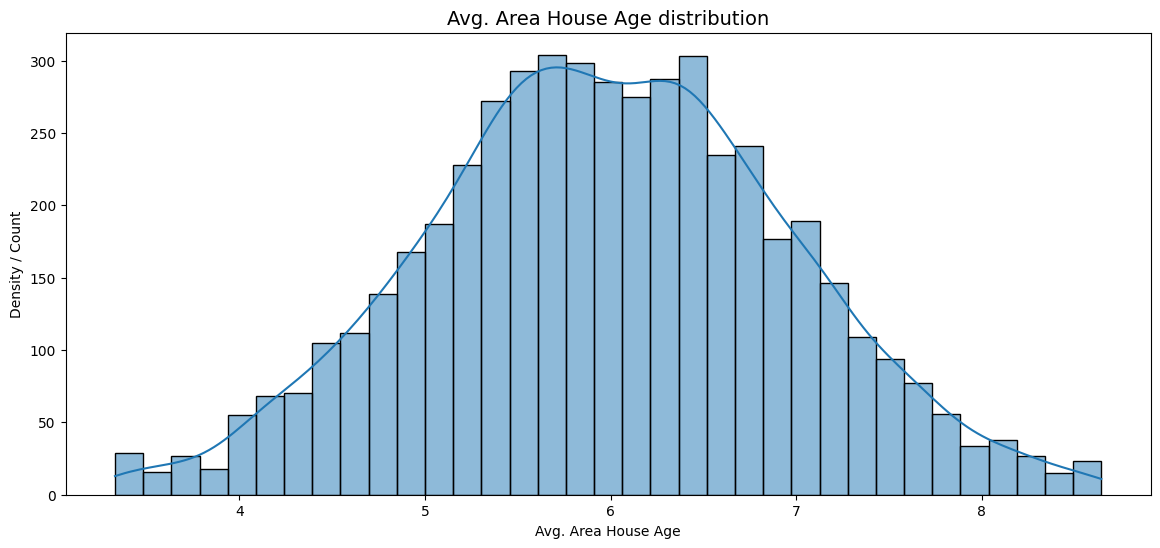

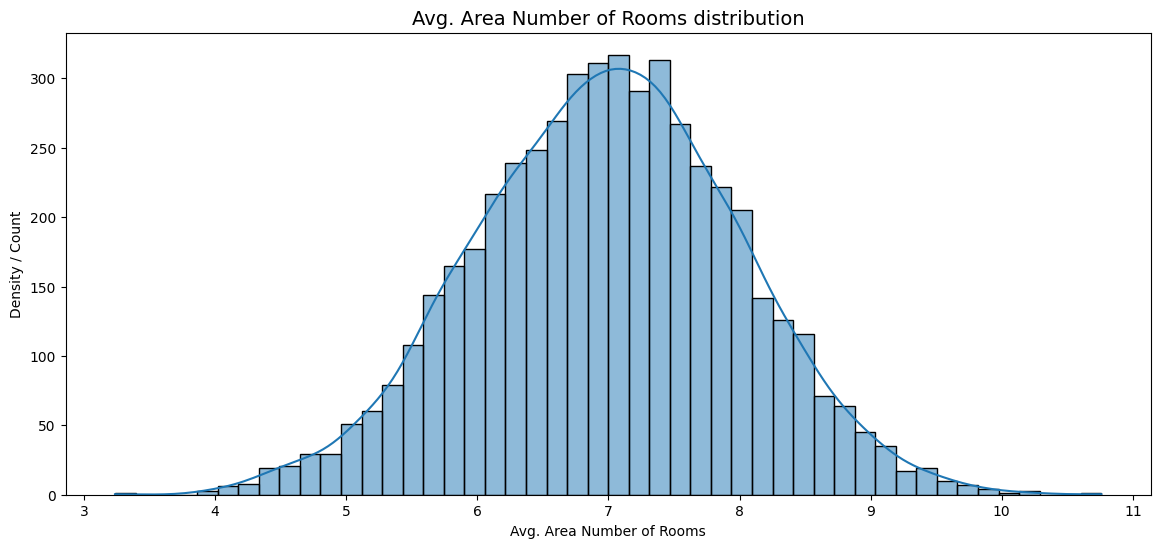

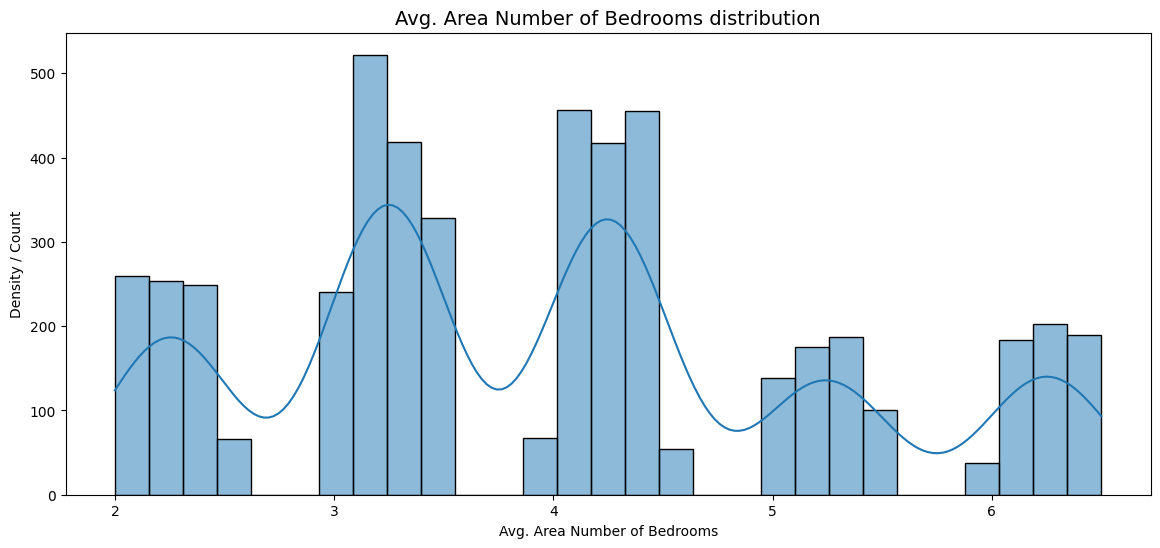

In [41]:
features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms']

# 2. Döngü ile her bir sütun için grafikleri otomatik oluşturun
for col in features:
    plt.figure(figsize=(14, 6)) 
    plt.tight_layout()
    
    # Seçilen sütunu ve KDE çizgisini çizdir
    sns.histplot(df[col], kde=True)
    # Grafiğe dinamik olarak o sütunun adını başlık yap
    plt.title(f'{col} distribution', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Density / Count')

    plt.show()


In [ ]:
def outlier_detection(cols):
    Q1,Q3 = np.percentile(cols,[25,75])
    IQR = Q3-Q1
    upper_bound = Q3 + (1.5*IQR)
    lower_bound = Q1 - (1.5*IQR)
    return upper_bound,lower_bound

In [26]:
list1 = ['Avg. Area Income', 'Price','Avg. Area House Age', 'Avg. Area Number of Bedrooms']

In [27]:
for cols in list1:
    upper_bound,lower_bound = outlier_detection(df[cols])
    df[cols] = np.clip(df[cols],a_min=lower_bound,a_max=upper_bound)

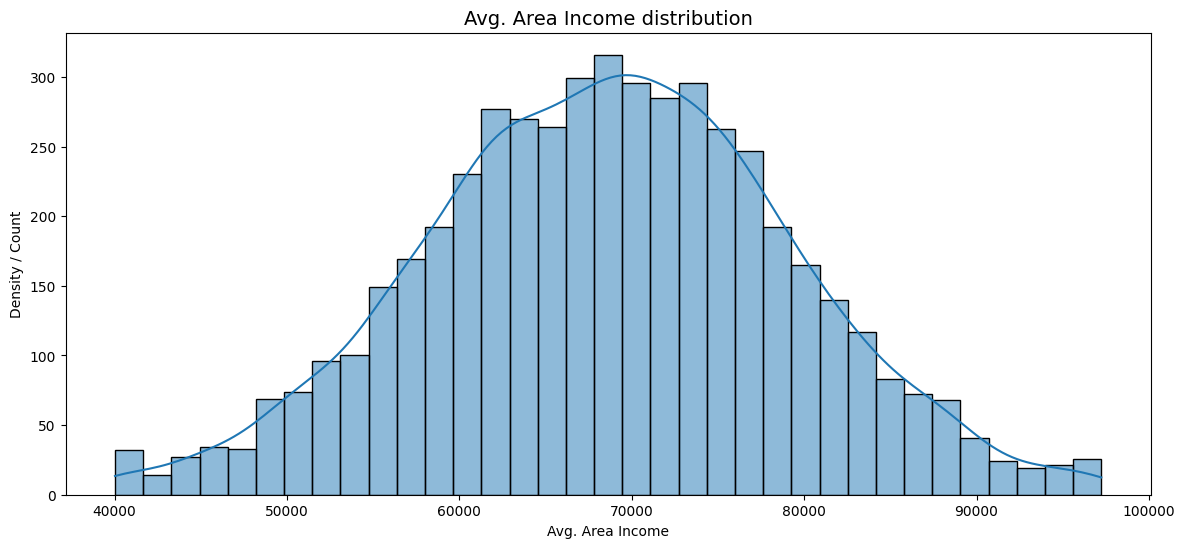

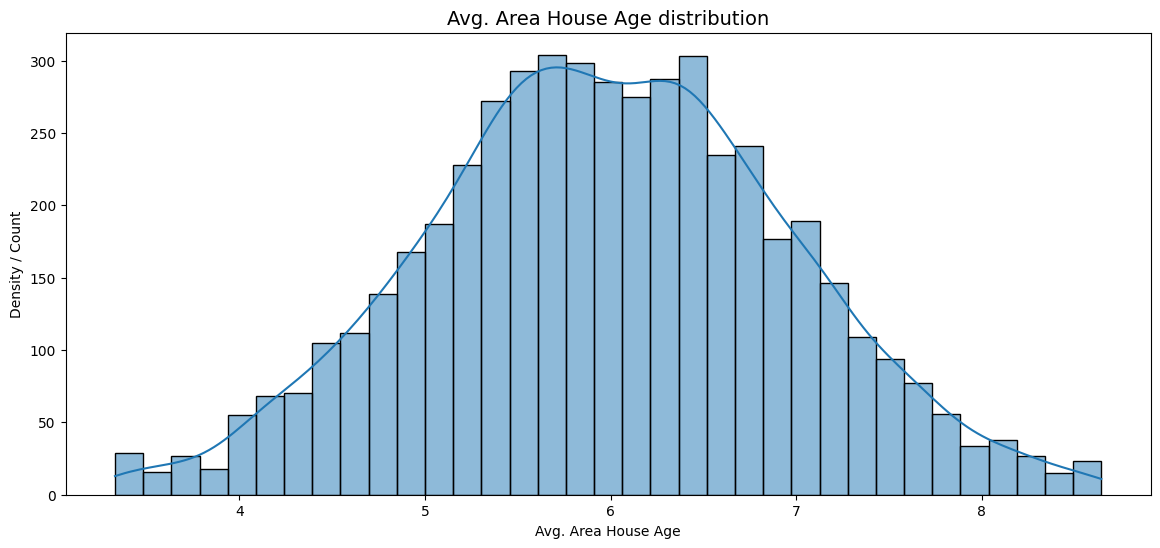

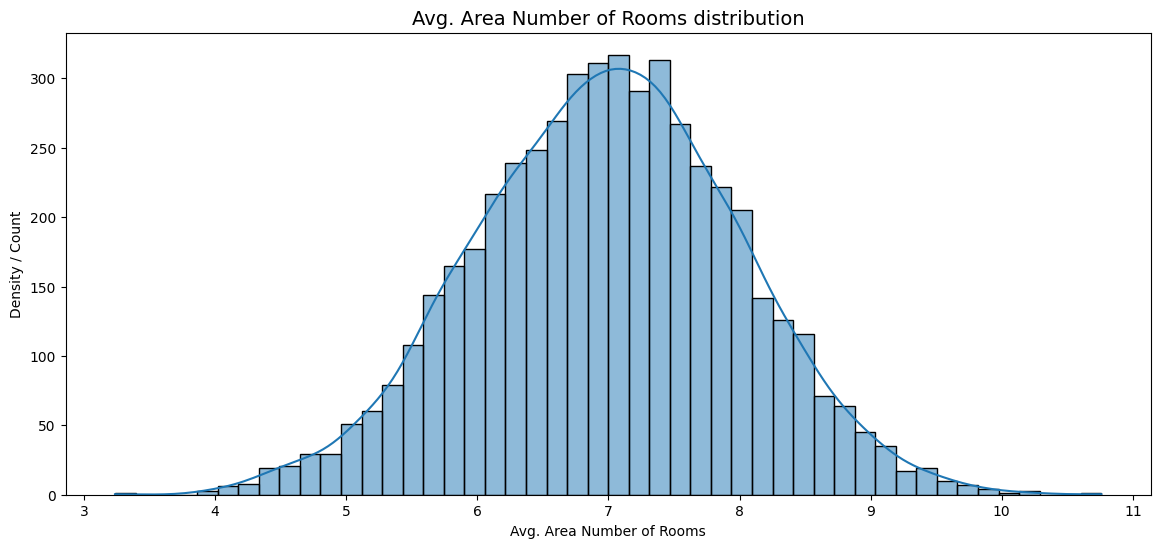

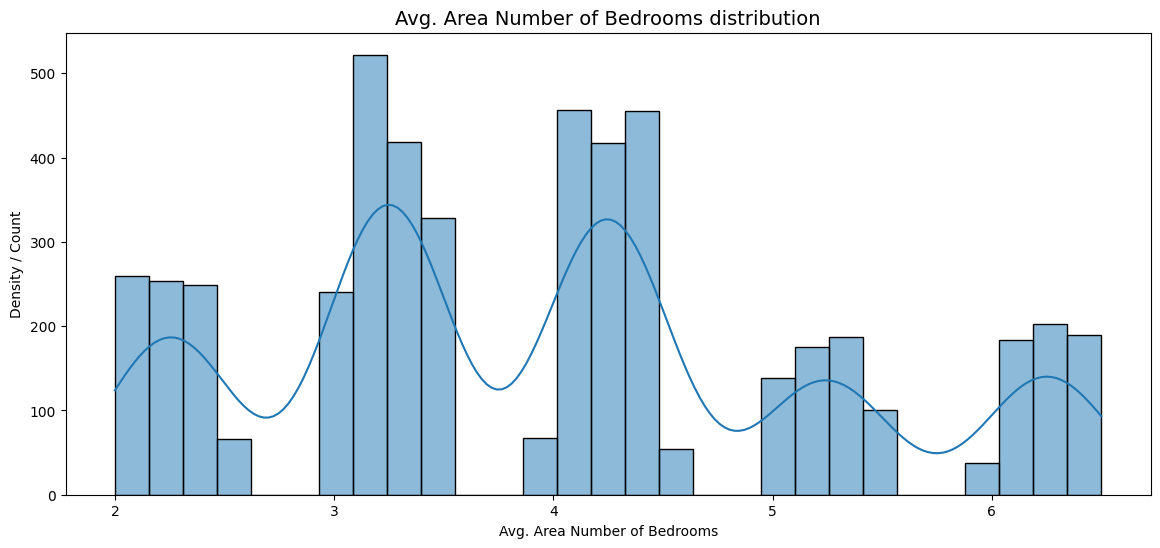

In [40]:
features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms']

# 2. Döngü ile her bir sütun için grafikleri otomatik oluşturun
for col in features:
    plt.figure(figsize=(14, 6)) 
    plt.tight_layout()
    
    # Seçilen sütunu ve KDE çizgisini çizdir
    sns.histplot(df[col], kde=True)
    
    # Grafiğe dinamik olarak o sütunun adını başlık yap
    plt.title(f'{col} distribution', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Density / Count')

    plt.show()

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x = df.drop(['Price'], axis=1)
y = df['Price']

In [45]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, 
                                                test_size=0.2, 
                                                random_state=1,
                                                shuffle=True
)

In [46]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(4000, 5)
(1000, 5)
(4000,)
(1000,)


In [47]:
model = LinearRegression()
model.fit(xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:
print(model.intercept_)
print(model.coef_)

-2632318.662679008
[2.16879850e+01 1.64961900e+05 1.20423856e+05 1.45998360e+03
 1.50557274e+01]


In [50]:
y_pred = model.predict(xtest)
y_pred_train = model.predict(xtrain)

In [51]:
y_pred

array([1553713.83354722, 1582172.58760065,  942472.20032282,
        943657.59046403, 1183745.40013542,  332546.95923726,
       1927936.3206273 , 1069611.54967542, 1648894.65567348,
       1071568.97037888,  626906.66210804, 1538999.01963475,
       1630456.12255401, 1056554.41734883,  961782.55662223,
       1234771.31862341, 1427909.90241588,  926377.54556175,
       1128179.67363239, 1157707.89391192, 1296946.7385856 ,
       1865414.31790192, 1182667.46257683, 1192027.22642195,
       1557014.61940074, 1861490.96103546,  815714.65995647,
       1062428.16600783, 1224922.15688239,  662678.06891378,
        842958.55150389, 1637037.61344247,  666901.33188698,
       1116062.859992  ,  801846.65489904, 1302861.59470223,
       1147432.84067261, 1352034.80506637, 1035131.96494549,
       1163070.9570319 , 1411688.09769314, 1308588.20116472,
       1575810.52795593, 1301134.77480613,  849750.91974823,
        924708.86687356, 1228394.56357633, 1161835.30209714,
       1419997.00226732,

In [52]:
ytest

2764    1.413580e+06
4767    1.618721e+06
3814    8.413925e+05
3499    8.814439e+05
2735    1.174748e+06
            ...     
448     1.309986e+06
921     1.059871e+06
4087    1.644923e+06
1242    1.106337e+06
2242    7.590447e+05
Name: Price, Length: 1000, dtype: float64

In [53]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [54]:
y.mean()

1232028.312777584

In [55]:
print("MAE:",round(mean_absolute_error(ytrain,y_pred_train),2))
print("RMSE:",round(np.sqrt(mean_squared_error(ytrain,y_pred_train)),2))
print("R**2:",round(r2_score(ytrain,y_pred_train),2))

MAE: 81248.73
RMSE: 100890.68
R**2: 0.92


In [56]:
print("MAE:",round(mean_absolute_error(ytest,y_pred),2))
print("RMSE:",round(np.sqrt(mean_squared_error(ytest,y_pred)),2))
print("R**2:",round(r2_score(ytest,y_pred),2))

MAE: 82357.08
RMSE: 102359.88
R**2: 0.92


In [59]:
data = pd.DataFrame({'Actual': ytest, 'Predicted': y_pred})
data

,Actual,Predicted
2764,1.413580e+06,1.553714e+06
4767,1.618721e+06,1.582173e+06
3814,8.413925e+05,9.424722e+05
3499,8.814439e+05,9.436576e+05
2735,1.174748e+06,1.183745e+06
...,...,...
448,1.309986e+06,1.427954e+06
921,1.059871e+06,9.534207e+05
4087,1.644923e+06,1.643607e+06
1242,1.106337e+06,1.008131e+06


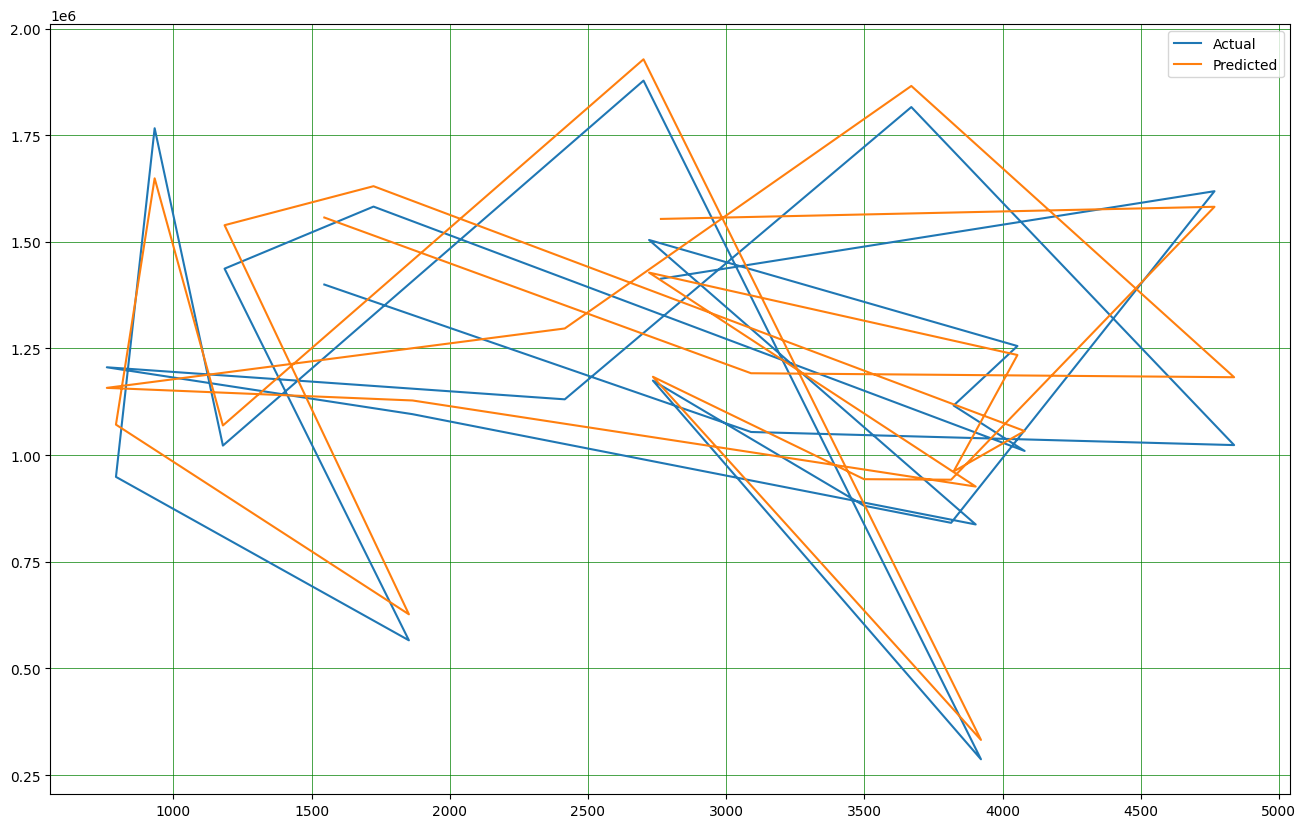

In [60]:
df1 = data.head(25)
df1.plot(kind='line',figsize=(16,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [ ]:
#R^2 = 0.92$ Ne Anlama Gelir?: Modeliniz, ev fiyatlarındaki değişimin %92'sini eldeki 5 özelliği (gelir, oda sayısı, ev yaşı vb.) kullanarak doğru bir şekilde açıklayabiliyor demektir. Bir regresyon modeli için %92 skor harika bir başarıdır.
#Overfitting (Aşırı Öğrenme) Yok!: Eğitim setindeki $R^2$ skoru ile test setindeki $R^2$ skoru birebir aynı (0.92). MAE ve RMSE hata değerleri de birbirine inanılmaz yakın. Bu bize modelinizin ezberlemediğini, gerçekten mantığı öğrendiğini ve yeni göreceği ev fiyatlarını da aynı başarıyla tahmin edeceğini gösterir.
